# Порядок выполнения проектной работы
### 1. Сбор и очистка данных
### 2. Анализ данных
### 3. Создание модели
### 4. Оценка качества модели




# <b>Обучение моделей и сравнение показателей точностей</b>

Построим две модели машинного обучения. Первая будет реализована самостоятельно при помощи градиентного спуска, а вторая - возможностями библиотеки sklearn.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive/


In [17]:
offers_filtered = pd.read_csv('final_data.csv')

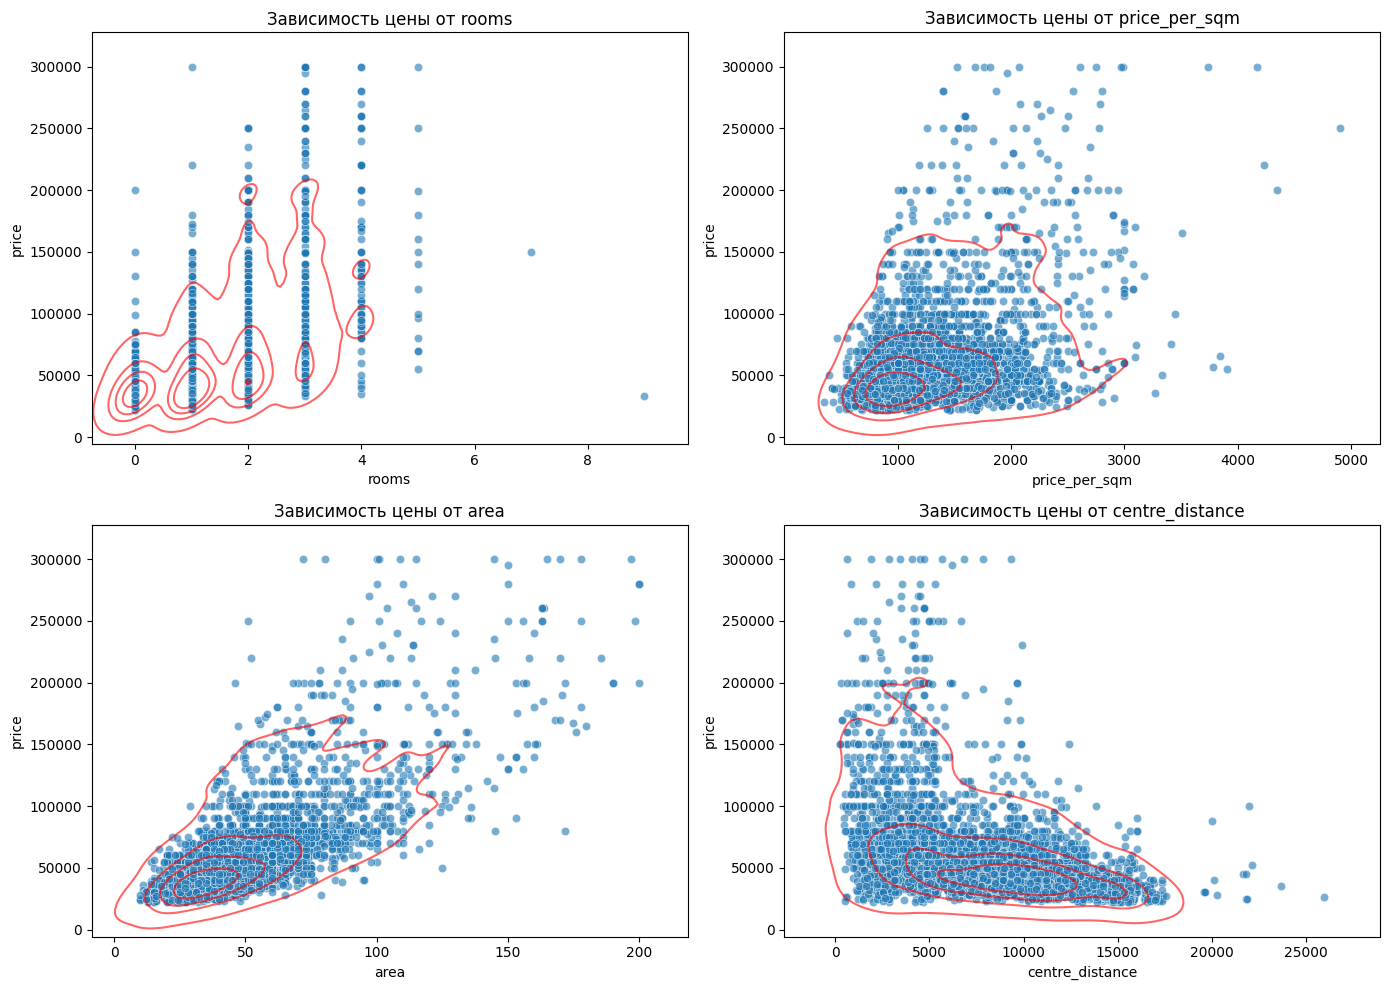

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
features = ['rooms', 'price_per_sqm', 'area', 'centre_distance']
for i, col in enumerate(features):
    sns.scatterplot(x=offers_filtered[col], y=offers_filtered['price'], ax=axes[i//2, i%2], alpha=0.6)
    sns.kdeplot(x=offers_filtered[col], y=offers_filtered['price'], ax=axes[i//2, i%2], alpha=0.6, levels=5, color='red')
    axes[i//2, i%2].set_title(f'Зависимость цены от {col}')
plt.tight_layout()
plt.show()

На графиках представлены 4 самые сильные зависимости цены от каждого признака по отдельности. Но так как поличество комнат и цена за квадратный метр сильно зависят от площади, то попробуем построить модель всего на двух признаках: площадь и расстояние до центра.

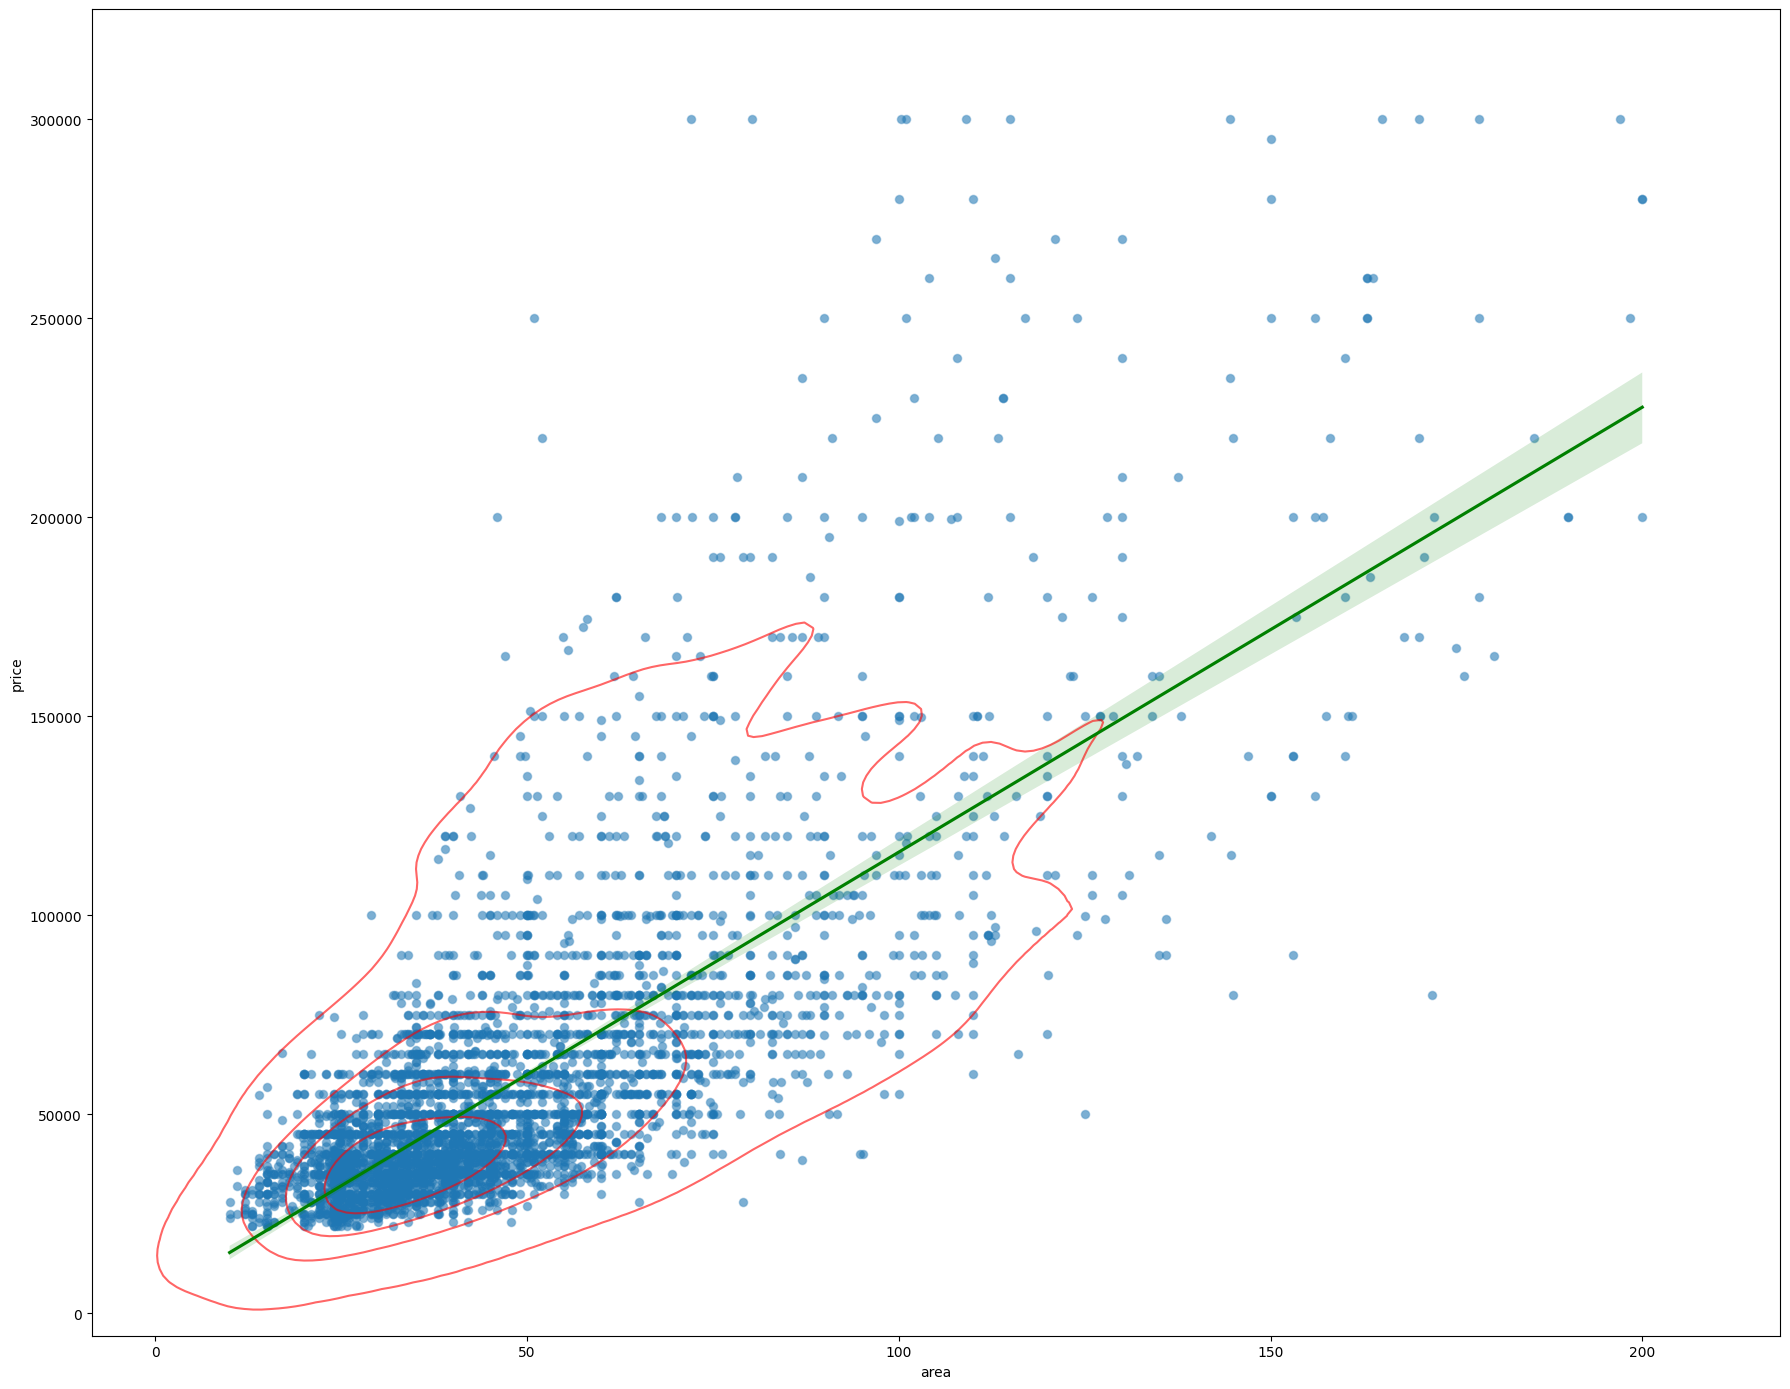

In [39]:
plt.figure(figsize=(18, 14))
sns.scatterplot(
    x=offers_filtered['area'], y=(offers_filtered['price']), alpha=0.4
    )
sns.kdeplot(x=offers_filtered['area'], y=(offers_filtered['price']), alpha=0.6, levels=5, color='red')
sns.regplot(x=offers_filtered['area'], y=(offers_filtered['price']), scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.tight_layout()

plt.show()

На графике представлена проксимация зависимости от площади.
График зависимости цены от площади удачнее всего можно свести к прямой.

Зависимость от цены от расстояния до центра представляется в виде гиперболы. Проверим теорию и приведем график к прямой при помощи обратной функции.

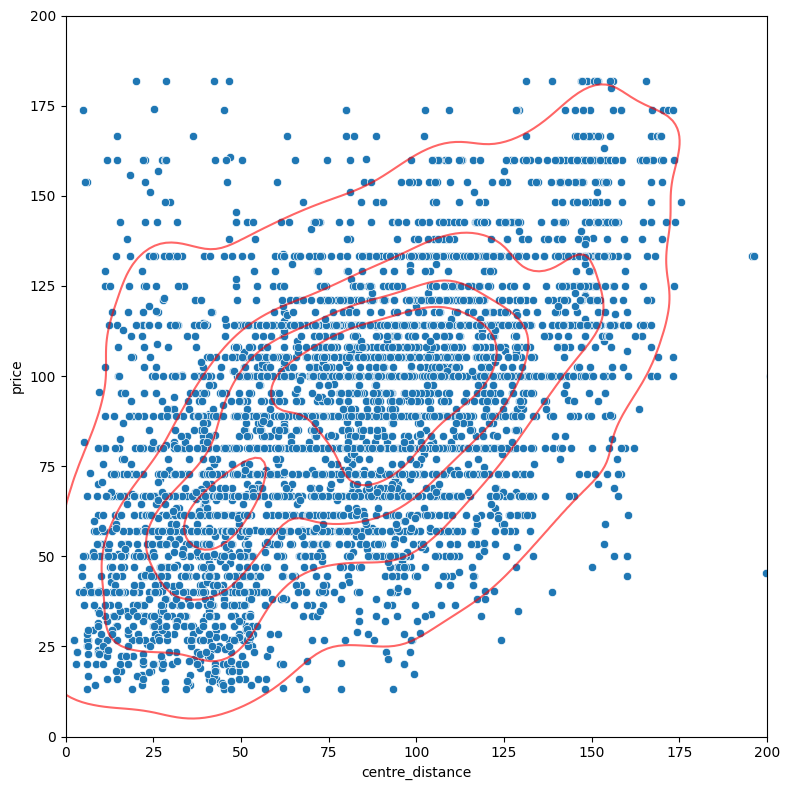

In [20]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=offers_filtered['centre_distance']/100, y=(4 * 10**6/offers_filtered['price'])
    )
sns.kdeplot(x=offers_filtered['centre_distance']/100, y=(4 * 10**6/offers_filtered['price']), alpha=0.6, levels=5, color='red')

plt.xlim(0, 200)
plt.ylim(0, 200)
plt.tight_layout()

plt.show()

Точки действительно выстроились в окрестности прямой y=x. Для предсказания будем использовать зависимость y = 1/centre_dist

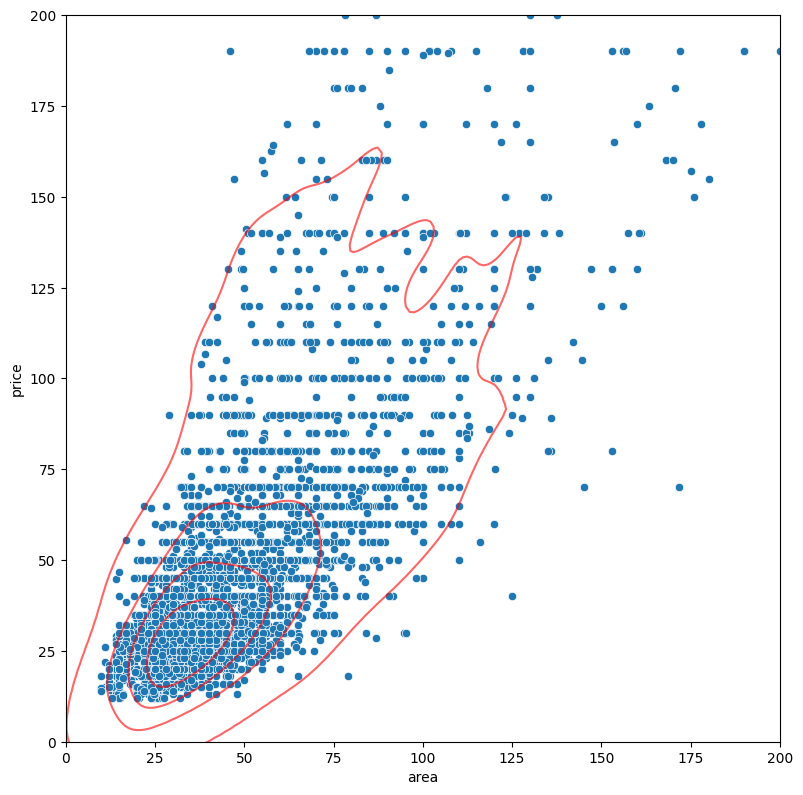

In [21]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=offers_filtered['area'], y=((offers_filtered['price'] -10000)/1000)
    )
sns.kdeplot(x=offers_filtered['area'], y=((offers_filtered['price'] -10000)/1000), alpha=0.6, levels=5, color='red')

plt.tight_layout()
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.show()

На графике представлен отмасштабированный график зависимости цены от площади.

# Создание моделей

**Подготовка данных**

Нормируем целевую переменную и признаки, запоминаем статистики для денормализации. Сохраняем матрицу признаков.

In [22]:
y = offers_filtered['price'].values.reshape(-1, 1)  # (n, 1)

area = offers_filtered['area'].values.reshape(-1, 1)
inv_dist = (1.0 / (offers_filtered['centre_distance'].values + 1)).reshape(-1, 1)

area_mean, area_std = np.mean(area), np.std(area)
inv_dist_mean, inv_dist_std = np.mean(inv_dist), np.std(inv_dist)
y_mean, y_std = np.mean(y), np.std(y)

area_norm = (area - area_mean) / area_std
inv_dist_norm = (inv_dist - inv_dist_mean) / inv_dist_std
y_norm = (y - y_mean) / y_std

n_samples = len(y)
X = np.column_stack([
    np.ones((n_samples, 1)),
    area_norm,
    inv_dist_norm
])

print(f"Форма X: {X.shape}")
print(f"Форма y: {y_norm.shape}")
print(f"Диапазон area: [{area.min():.1f}, {area.max():.1f}]")
print(f"Диапазон 1/dist: [{inv_dist.min():.4f}, {inv_dist.max():.4f}]")

Форма X: (4563, 3)
Форма y: (4563, 1)
Диапазон area: [10.0, 200.0]
Диапазон 1/dist: [0.0000, 0.0040]


**Функции для градиентного спуска**

Функции для предсказания значения по входным признакам, вычисления функии потерь и градиента.

In [23]:
def predict(X, theta):
    """
    X: (n, 3) матрица признаков
    theta: (3, 1) вектор параметров
    return: (n, 1) вектор предсказаний
    """
    return X @ theta


def compute_cost(X, y, theta):
    """
    Функция потерь MSE: J = (1/2m) * Σ(h - y)^2
    MSE = 2 * J / m
    """
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


def compute_gradient(X, y, theta):
    """
    Градиент функции потерь: ∇J = (1/m) * X^T @ (X @ theta - y)
    X: (n, 3)
    y: (n, 1)
    theta: (3, 1)
    return: (3, 1) градиент
    """
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return gradient

**Градиентный спуск**

Зададим начальные значения и гиперпараметры и проведем градиентный спуск.

In [24]:
theta = np.zeros((3, 1))

learning_rate = 0.1
n_iterations = 1000
tolerance = 1e-8

cost_pred = 0
cost_now = 0

for iteration in range(n_iterations):

    gradient = compute_gradient(X, y_norm, theta)

    theta = theta - learning_rate * gradient

    cost = compute_cost(X, y_norm, theta)
    cost_pred = cost_now
    cost_now = cost

    if iteration > 0:
        if abs(cost_now - cost_pred) < tolerance:
            print(f"Сошлось на итерации {iteration}")
            break

print(f"{'Итер':>5} | {'Cost':>12} | {'Theta0':>10} | {'Theta1':>10} | {'Theta2':>10}")
print(f"{iteration:5d} | {cost:12.6f} | {theta[0,0]:10.4f} | "
      f"{theta[1,0]:10.4f} | {theta[2,0]:10.4f}")

Сошлось на итерации 88
 Итер |         Cost |     Theta0 |     Theta1 |     Theta2
   88 |     0.206018 |     0.0000 |     0.7017 |     0.1756


**Денормализация данных**

Возвращение к исходным коэффициентам.

In [25]:
# Нормированная модель
# y_norm = θ0 + θ1*area_norm + θ2*inv_dist_norm
#
# (y - y_mean)/y_std = θ0 + θ1*(area - area_mean)/area_std + θ2*(inv_dist - inv_dist_mean)/inv_dist_std


beta_0 = y_std * (theta[0, 0]
                  - theta[1, 0] * area_mean / area_std
                  - theta[2, 0] * inv_dist_mean / inv_dist_std) + y_mean

beta_1 = theta[1, 0] * y_std / area_std
beta_2 = theta[2, 0] * y_std / inv_dist_std

print("Исходный масштаб")
print(f"Intercept = {beta_0:.2f}")
print(f"Area      = {beta_1:.2f}  (вклад площади)")
print(f"1/Dist    = {beta_2:.2f}  (вклад обратного расстояния)")
print()
print(f"price = {beta_0:.0f} + {beta_1:.0f} * area + {beta_2:.0f} / (distance + 1)")

Исходный масштаб
Intercept = 1799.05
Area      = 1049.04  (вклад площади)
1/Dist    = 28793508.29  (вклад обратного расстояния)

price = 1799 + 1049 * area + 28793508 / (distance + 1)


**Метрики качества**

Оценим качество получившейся модели.

In [27]:
X_original = np.column_stack([
    np.ones((n_samples, 1)),
    area,
    inv_dist
])
theta_original = np.array([[beta_0], [beta_1], [beta_2]])
y_pred = X_original @ theta_original


residuals = y - y_pred
sse = np.sum(residuals ** 2)
sst = np.sum((y - y_mean) ** 2)
r_squared = 1 - sse / sst
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(residuals))
mape = np.mean(np.abs(residuals / y)) * 100

print(f"R^2       = {r_squared:.4f}")
print(f"RMSE      = {rmse:.2f} руб")
print(f"MAE       = {mae:.2f} руб")
print(f"MAPE      = {mape:.2f}%")

R^2       = 0.5880
RMSE      = 24130.53 руб
MAE       = 15056.45 руб
MAPE      = 25.52%


Для двух признаков модель показывает неплохой результат, но оценка достаточно грубая. В среднем модель ошибается на 25% от реальной цены. Модель объясняет 59% цены квартиры, остальное - влияние других признаков. Такие показатели говорят о том, что площадь и расстояние до центра - действительно ключевые параметры формирования цены.

Теперь создадим модель встроенными возможностями библиотеки sklearn и сравним результаты.

In [28]:
X = offers_filtered[['area', 'rooms', 'centre_distance']]
y = offers_filtered['price']

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))

print("Признаки (X) после масштабирования:")
print(X_scaled[:5])
print("\nЦелевая переменная (y) после масштабирования:")
print(y_scaled[:5])

Признаки (X) после масштабирования:
[[ 1.28938823  1.6071433  -0.57429477]
 [ 4.86838108  2.57563179 -1.88623159]
 [ 0.1361572   0.6386548   0.07417586]
 [ 1.07862532  1.6071433  -1.15105586]
 [-0.07858237  0.6386548   0.34392538]]

Целевая переменная (y) после масштабирования:
[[ 1.2711186 ]
 [ 6.45835265]
 [-0.19194741]
 [ 2.73418461]
 [-0.19194741]]


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Прогнозирование
y_pred_lin = lin_reg.predict(X_test_scaled)

# Оценка качества
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f'Линейная модель -> MSE: {mse_lin:.2f}, R2: {r2_lin:.4f}')
print('Коэффициенты модели:', dict(zip(X.columns, lin_reg.coef_)))

Линейная модель -> MSE: 575591150.44, R2: 0.6524
Коэффициенты модели: {'area': np.float64(29940.348197075302), 'rooms': np.float64(-6082.198934535212), 'centre_distance': np.float64(-10488.402937101764)}


Линейная модель показала результаты лучше, чем первая модель, но к ней был добавлен признак зависимости от количества комнат. (0.6524 > 0.5880).

In [32]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Получаем имена новых признаков
poly_features = poly.get_feature_names_out(X.columns)
print("Примеры полиномиальных признаков:", poly_features[:10])

Примеры полиномиальных признаков: ['area' 'rooms' 'centre_distance' 'area^2' 'area rooms'
 'area centre_distance' 'rooms^2' 'rooms centre_distance'
 'centre_distance^2']


In [33]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Прогнозирование
y_pred_poly = poly_reg.predict(X_test_poly)

# Оценка качества
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Полиномиальная модель (степень 2) -> MSE: {mse_poly:.2f}, R2: {r2_poly:.4f}')

Полиномиальная модель (степень 2) -> MSE: 562254363.92, R2: 0.6604


Полиномиальная модель оказалась почти такой же по точности, как и линейная.

In [40]:
print("Сравнение моделей")
print(f"Линейная модель:      R2 = {r2_lin:.4f}, MSE = {mse_lin:.2f}")
print(f"Полиномиальная модель: R2 = {r2_poly:.4f}, MSE = {mse_poly:.2f}")

Сравнение моделей
Линейная модель:      R2 = 0.6524, MSE = 575591150.44
Полиномиальная модель: R2 = 0.6604, MSE = 562254363.92


Посмотрим наглядно на графике результаты предсказаний.

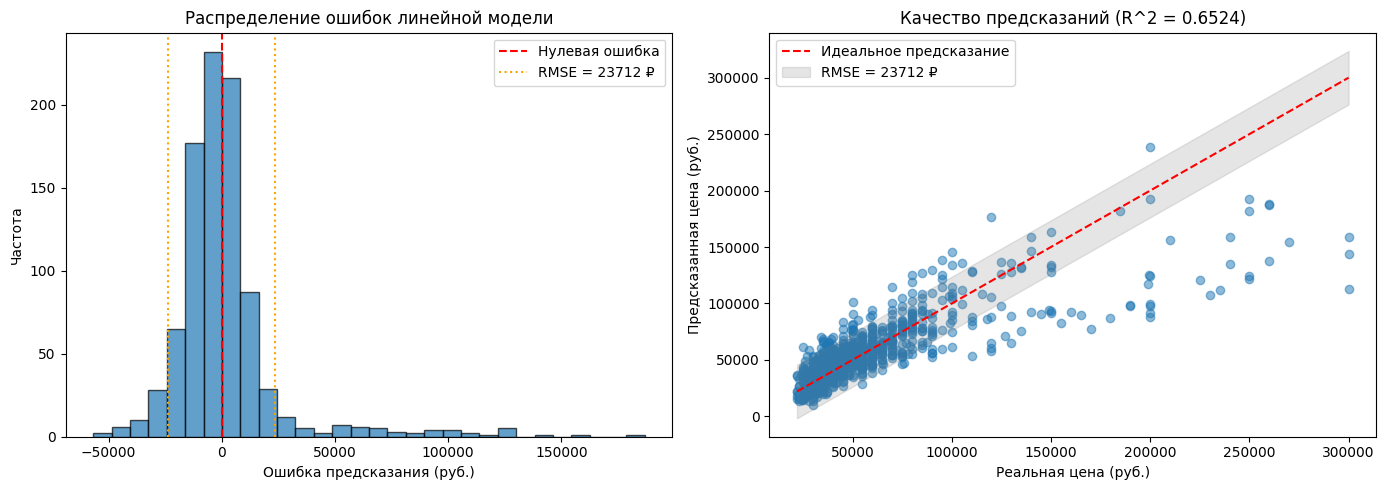

Статистика ошибок:
Средняя ошибка: 1032 руб.
Стандартное отклонение ошибки: 23969 руб.
65% предсказаний в пределах: 23969 руб.
95% предсказаний в пределах: 47939 руб.


In [35]:

import matplotlib.pyplot as plt

# ошибки для линейной модели
residuals = y_test - y_pred_lin
rmse = np.sqrt(562254363.92)

# график распределения ошибок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма ошибок
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='Нулевая ошибка')
axes[0].axvline(x=-rmse, color='orange', linestyle=':', label=f'RMSE = {rmse:.0f} ₽')
axes[0].axvline(x=rmse, color='orange', linestyle=':')
axes[0].set_xlabel('Ошибка предсказания (руб.)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение ошибок линейной модели')
axes[0].legend()

# предсказанные vs реальные цены
axes[1].scatter(y_test, y_pred_lin, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Идеальное предсказание')
axes[1].fill_between([y_test.min(), y_test.max()],
                      [y_test.min()-rmse, y_test.max()-rmse],
                      [y_test.min()+rmse, y_test.max()+rmse],
                      alpha=0.2, color='gray', label=f'RMSE = {rmse:.0f} ₽')
axes[1].set_xlabel('Реальная цена (руб.)')
axes[1].set_ylabel('Предсказанная цена (руб.)')
axes[1].set_title(f'Качество предсказаний (R^2 = {r2_lin:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

# анализ выбросов
print("Статистика ошибок:")
print(f"Средняя ошибка: {np.mean(residuals):.0f} руб.")
print(f"Стандартное отклонение ошибки: {np.std(residuals):.0f} руб.")
print(f"{round(r2_lin * 100)}% предсказаний в пределах: {np.std(residuals):.0f} руб.")
print(f"95% предсказаний в пределах: {2*np.std(residuals):.0f} руб.")

# **Вывод**

В результате проектной работы были собраны данные о предложениях по аренде квартир в Санкт-Петербурге. Проведен анализ зависимости данных, построены графики завсимостей и матрица корреляций. Выбраны самые значимые признаки для обучения. Построены три модели. Первая реализована градиентным спуском на основе двух признаков (площадь и расстояние до центра). Вторая представляет линейную регрессию возможностями библиотеки sklearn на трех признаках (площадь, этаж, расстояние до центра). Третья - полиномиальная регрессия второй степени, также на библиотеке sklearn по трем признакам. Все три модели показали неплохие метрики, результаты представлены на графиках.